In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk
#from NN_utils import load_vstate

#from correlations import correlations_vstate


jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
jax.devices()

[CudaDevice(id=0)]

In [2]:

import sys
from pathlib import Path
sys.path.append(str("/home/ihuarte/Escritorio/Ivan/ATMOS_VA/VA_project/src"))

from VA_project.model.model import OxalateJKGamma
from VA_project.engine.runners import Runner
from NN_module.sim_utils import (
    load_vstate
)
files=[
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_128_heads_2_blocks_2_ffn_lay_2.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_8_blocks_2_ffn_lay_4.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_2_blocks_2_ffn_lay_4.json"
]

size=[4,4]
strength=0.2
theta=54.
phi=0.
kwargs_lattice={
    'bc':'periodic',
    'order':'default_2'
}

oxa=OxalateJKGamma(
            size, 
            [strength, theta, phi],
            **kwargs_lattice
        )
H = Runner(oxa.cm).build_hamiltonian()
E_ED, x_ED = Runner(oxa.cm).exact_energy_lanczos(eigenstates=True, k=150)
idx=np.argsort(E_ED)
E_ED=E_ED[idx]
x_ED=x_ED.T[idx,:]

In [14]:
i=2
path_artifact= files[i]

with open(path_artifact,'r') as f:
    artifact = json.load(f)

vstate=load_vstate(artifact).to_array()
vstate=np.array(vstate, dtype=np.complex128)


In [15]:
c=np.sum(x_ED.conjugate()*vstate, axis=1)
P=np.abs(c)**2
sum(P)

np.float64(0.135464914189455)

In [16]:
E_best=artifact['results']['E_best']
e=-np.inf; idx=0
while e<E_best:
    e=E_ED[idx]
    idx+=1

idx, E_ED[idx],E_ED[idx-1]

(4, np.float64(-1.5469373598988332), np.float64(-1.5469373598989151))

Text(0.5, 0.8, '$\\Sigma_i\\; P_i = 0.1355$\n$E_1=-1.610$\n$E_{150}=-1.374$\n$E_{sim}=-1.555$')

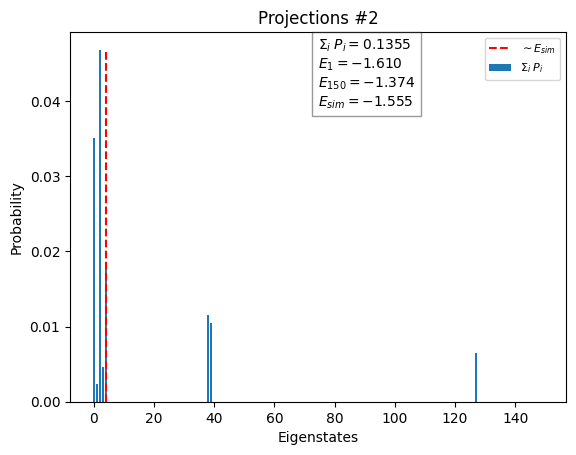

In [18]:
P_sum=sum(P)

_,ax=plt.subplots()
ax.set_title(f"Projections #{i}")
ax.set_xlabel("Eigenstates")
ax.set_ylabel("Probability")
ax.bar(range(len(P)), P, label=r"$\Sigma_i\; P_i$")
ax.vlines(idx, 0,max(P), color='r', ls='--', label=r"$\sim E_{sim}$")
ax.legend(fontsize=8)
ax.text(0.5, 0.8, r"$\Sigma_i\; P_i = %.4f$"%P_sum+"\n"+r"$E_1=%.3f$"%E_ED[0]+"\n"+r"$E_{150}=%.3f$"%(E_ED[-1])+"\n"+r"$E_{sim}=%.3f$"%E_best, transform=ax.transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.4))
#ax.set_yscale('log')

In [12]:
a=False
b=True
not a and b

True

# Learning Rate Scheduler

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
def cos_exp(epochs,lr0,decay,cycles, n, lr_min):
    exp = lambda x, a: jnp.exp(-a*x/(epochs))
    cos = lambda x, cycles: jnp.cos(x*2*jnp.pi/(epochs) *(cycles-0.5))
    line = lambda x, n: (lr_min-n)/epochs*x+n
    x=np.arange(0,epochs)
    return (lr0-n)*exp(x,decay)*(1+cos(x,cycles))/2+line(x,n)

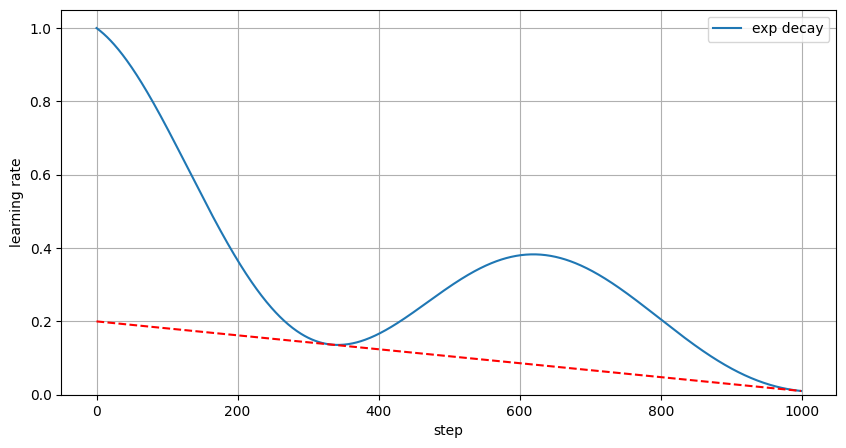

In [ ]:
#exp = lambda x: (1.0-0.1)*0.99**x 
epochs = 1000
lr_0 = 1
decay=1.5
cycles=2
lr_min=0.01
n=0.2

recta = lambda x: (lr_min-n)/epochs*x+n
y_recta=recta(jnp.arange(0,epochs))

y=cos_exp(epochs,lr_0,decay,cycles,n,lr_min)

_,ax= plt.subplots(1,1,figsize=(10,5))
ax.plot(y, label="exp decay")
ax.plot(np.arange(epochs),y_recta, ls= '--', color='r')
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid()

In [92]:
np.arange(0,epochs)

array([   0,    1,    2, ..., 9997, 9998, 9999], shape=(10000,))

In [ ]:
import jax.numpy as jnp
import jax
a= jnp.ones((4,4), dtype=complex)/10
b= jnp.ones((4,4) ,dtype=complex)


stack=jnp.array([a,b]).transpose(1,0,2)
z2_sym=jax.nn.logsumexp(
    stack,
    b=jnp.array([1., -1.])[None,:,None],
    axis=1
)
z2_2d_symm=jax.nn.logsumexp(
    z2_sym,
    axis=0
)

In [4]:
0.0993*36

3.5747999999999998